<a href="https://colab.research.google.com/github/IvankoPilotOfHalychyna/Foundations_AI/blob/main/POSI_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# POSI Final Project: Chicago Food Inspections Analysis
# Аналіз даних перевірок ресторанів з використанням Machine Learning

# ========================================
# КРОК 1: ІМПОРТ БІБЛІОТЕК
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML бібліотеки
#from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import LabelEncoder, StandardScaler
#rom sklearn.linear_model import LogisticRegression
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
#from sklearn.cluster import KMeans
#

# ML бібліотеки
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score, roc_curve


# Налаштування візуалізації
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Бібліотеки завантажено успішно!")


✓ Бібліотеки завантажено успішно!


In [ ]:
# ========================================
# КРОК 2: ЗАВАНТАЖЕННЯ ДАНИХ
# ========================================

# Завантаж свій CSV файл (замість 'food_inspections.csv' вкажи свій шлях)
# Якщо файл у Google Colab, спочатку завантаж його:
# from google.colab import files
# uploaded = files.upload()

# Читання даних
df = pd.read_csv('food_inspections.csv')

print(f"✓ Дані завантажено!")
print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} колонок")
print("\nПерші 5 рядків:")
print(df.head())


✓ Дані завантажено!
Розмір датасету: 303139 рядків, 17 колонок

Перші 5 рядків:
   Inspection ID                     DBA Name                AKA Name  \
0        2629471  Patrick Sullivan Apartments     Sullivan Apartments   
1        2629464       TACOS LOS BROTHERS LLC  TACOS LOS BROTHERS LLC   
2        2629462                DUNKIN DONUTS           DUNKIN DONUTS   
3        2629517                  DEVON SHELL             DEVON SHELL   
4        2629473                     WINGTIPS     WINGTIPS (T-5 M-19)   

   License #  Facility Type             Risk              Address     City  \
0  2098634.0   Golden Diner    Risk 1 (High)    1633 W Madison ST  CHICAGO   
1  3065099.0     Restaurant    Risk 1 (High)  2607 S KOSTENER AVE  CHICAGO   
2  2437866.0     Restaurant  Risk 2 (Medium)        825 W 47TH ST  CHICAGO   
3  1798130.0  Grocery Store     Risk 3 (Low)      6346 N CLARK ST  CHICAGO   
4  3060521.0     Restaurant  Risk 2 (Medium)    11601 W TOUHY AVE  CHICAGO   

  State     


EXPLORATORY DATA ANALYSIS

--- Інформація про колонки ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303139 entries, 0 to 303138
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Inspection ID    303139 non-null  int64  
 1   DBA Name         303139 non-null  object 
 2   AKA Name         300724 non-null  object 
 3   License #        303120 non-null  float64
 4   Facility Type    297857 non-null  object 
 5   Risk             303053 non-null  object 
 6   Address          303139 non-null  object 
 7   City             302965 non-null  object 
 8   State            303073 non-null  object 
 9   Zip              303098 non-null  float64
 10  Inspection Date  303139 non-null  object 
 11  Inspection Type  303138 non-null  object 
 12  Results          303139 non-null  object 
 13  Violations       218272 non-null  object 
 14  Latitude         302101 non-null  float64
 15  Longitude        302101 no

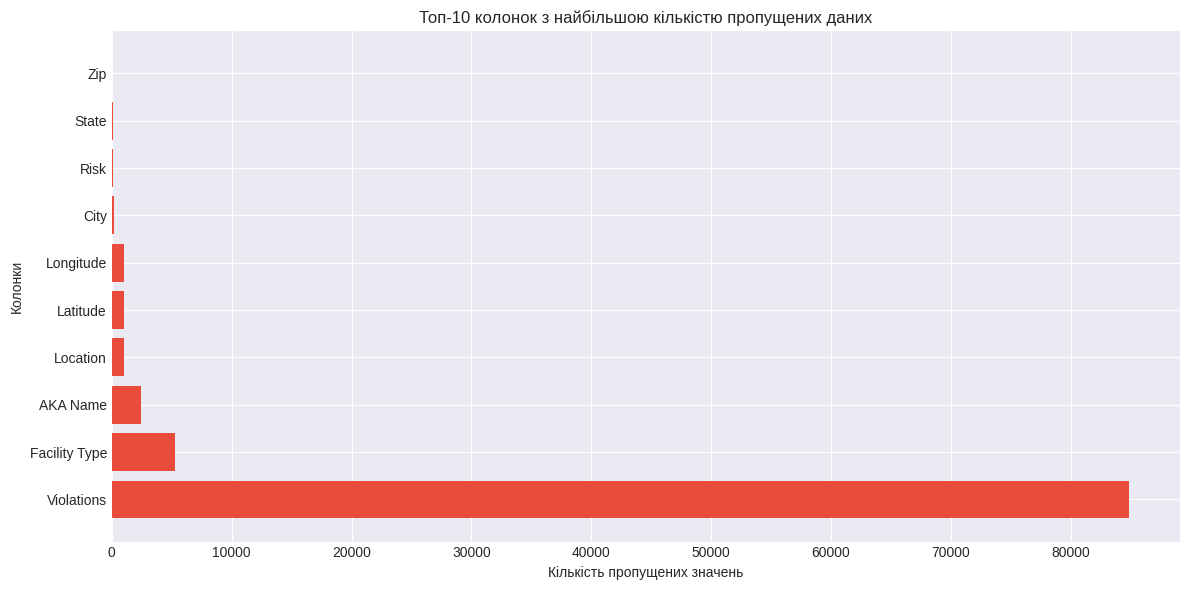


✓ Показано топ-10 з 12 колонок з пропущеними даними

--- Розподіл результатів перевірок ---
Results
Pass                    156680
Fail                     58513
Pass w/ Conditions       45196
Out of Business          25133
No Entry                 13314
Not Ready                 4209
Business Not Located        94
Name: count, dtype: int64


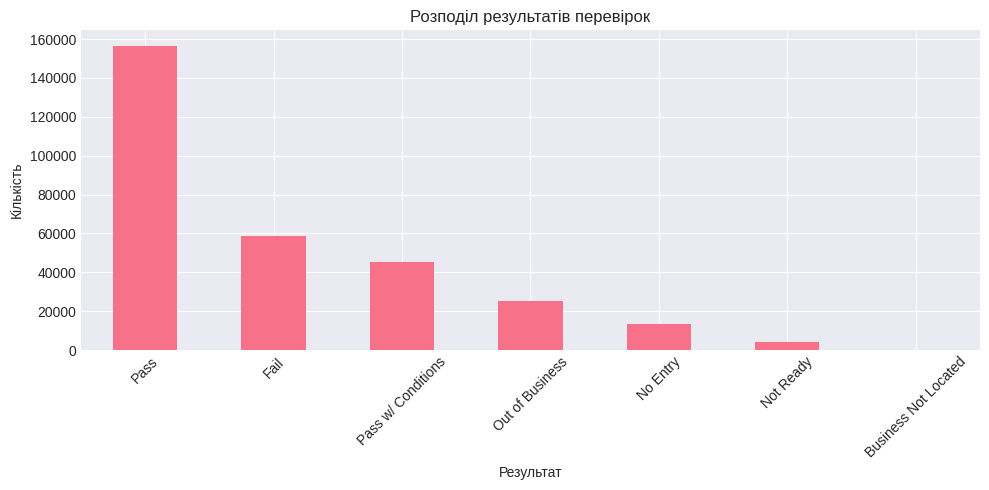


--- Топ-10 типів закладів ---
Facility Type
Restaurant                         205119
Grocery Store                       36741
School                              18927
Children's Services Facility         7282
Bakery                               4384
Daycare Above and Under 2 Years      4043
Daycare (2 - 6 Years)                3223
Long Term Care                       2349
Catering                             1882
Liquor                               1302
Name: count, dtype: int64


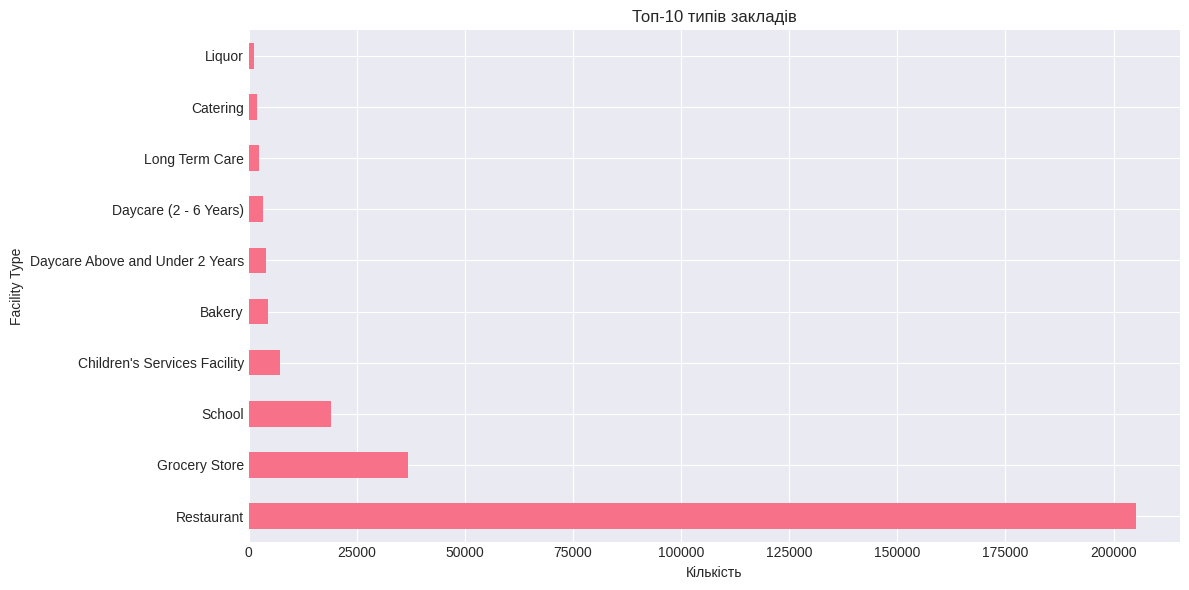


--- Розподіл рівнів ризику ---
Risk
Risk 1 (High)      224429
Risk 2 (Medium)     54773
Risk 3 (Low)        23773
All                    78
Name: count, dtype: int64


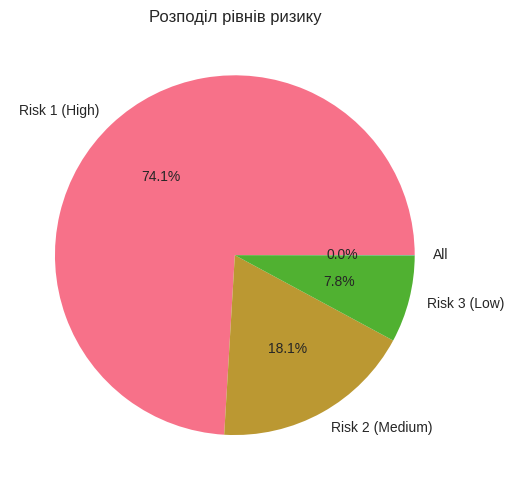

In [ ]:

# ========================================
# КРОК 3: EXPLORATORY DATA ANALYSIS (EDA)
# ========================================

print("\n" + "="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)

# 3.1 Загальна інформація про дані
print("\n--- Інформація про колонки ---")
print(df.info())

# 3.2 Статистичний опис
print("\n--- Статистичний опис ---")
print(df.describe())

# 3.3 Пропущені значення
print("\n--- Пропущені значення ---")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Колонка': missing.index,
    'Пропущено': missing.values,
    'Відсоток': missing_percent.values
})
print(missing_df[missing_df['Пропущено'] > 0])

# 3.4 Візуалізація пропущених даних
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    # Беремо тільки топ-10 колонок з найбільшою кількістю пропущених
    top_missing = missing_data.head(10)

    # Скорочуємо довгі назви колонок
    short_names = []
    for name in top_missing.index:
        if len(str(name)) > 40:
            short_names.append(str(name)[:37] + '...')
        else:
            short_names.append(str(name))

    plt.figure(figsize=(12, 6))
    plt.barh(range(len(top_missing)), top_missing.values, color='#e74c3c')
    plt.yticks(range(len(top_missing)), short_names)
    plt.xlabel('Кількість пропущених значень')
    plt.ylabel('Колонки')
    plt.title('Топ-10 колонок з найбільшою кількістю пропущених даних')
    plt.tight_layout()
    plt.show()

    print(f"\n✓ Показано топ-10 з {len(missing_data)} колонок з пропущеними даними")

# 3.5 Аналіз цільової змінної (Results)
if 'Results' in df.columns:
    print("\n--- Розподіл результатів перевірок ---")
    print(df['Results'].value_counts())

    plt.figure(figsize=(10, 5))
    df['Results'].value_counts().plot(kind='bar')
    plt.title('Розподіл результатів перевірок')
    plt.xlabel('Результат')
    plt.ylabel('Кількість')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 3.6 Аналіз типів закладів
if 'Facility Type' in df.columns:
    print("\n--- Топ-10 типів закладів ---")
    print(df['Facility Type'].value_counts().head(10))

    plt.figure(figsize=(12, 6))
    df['Facility Type'].value_counts().head(10).plot(kind='barh')
    plt.title('Топ-10 типів закладів')
    plt.xlabel('Кількість')
    plt.tight_layout()
    plt.show()

# 3.7 Аналіз рівня ризику
if 'Risk' in df.columns:
    print("\n--- Розподіл рівнів ризику ---")
    print(df['Risk'].value_counts())

    plt.figure(figsize=(8, 5))
    df['Risk'].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title('Розподіл рівнів ризику')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

In [ ]:
# ========================================
# КРОК 4: ПІДГОТОВКА ДАНИХ
# ========================================

print("\n" + "="*50)
print("ПІДГОТОВКА ДАНИХ ДЛЯ MACHINE LEARNING")
print("="*50)

# Створюємо копію для роботи
df_clean = df.copy()

# 4.1 Видалення непотрібних колонок (але ЗАЛИШАЄМО Zip для аналізу!)
# ВАЖЛИВО: Не видаляємо Zip, бо він потрібен для дослідницьких питань
columns_to_drop = ['License #', 'AKA Name', 'Address', 'City', 'State']
columns_to_drop = [col for col in columns_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=columns_to_drop, errors='ignore')

# 4.2 Обробка дат (якщо є колонка 'Inspection Date')
if 'Inspection Date' in df_clean.columns:
    df_clean['Inspection Date'] = pd.to_datetime(df_clean['Inspection Date'], errors='coerce')
    df_clean['Year'] = df_clean['Inspection Date'].dt.year
    df_clean['Month'] = df_clean['Inspection Date'].dt.month
    df_clean['DayOfWeek'] = df_clean['Inspection Date'].dt.dayofweek
    df_clean = df_clean.drop('Inspection Date', axis=1)

# 4.3 Фільтруємо дані для бінарної класифікації (Pass vs Fail)
if 'Results' in df_clean.columns:
    # Залишаємо тільки Pass та Fail
    df_clean = df_clean[df_clean['Results'].isin(['Pass', 'Fail', 'Pass w/ Conditions'])]

    # Створюємо бінарну цільову змінну: Pass = 1, Fail/Conditions = 0
    df_clean['Target'] = df_clean['Results'].apply(
        lambda x: 1 if x == 'Pass' else 0
    )

    print(f"✓ Цільова змінна створена. Розподіл:")
    print(df_clean['Target'].value_counts())

# 4.4 Видалення рядків з пропущеними значеннями у ключових колонках
important_cols = ['Results', 'Risk', 'Facility Type']
important_cols = [col for col in important_cols if col in df_clean.columns]
df_clean = df_clean.dropna(subset=important_cols)

print(f"\n✓ Після очищення: {df_clean.shape[0]} рядків")


ПІДГОТОВКА ДАНИХ ДЛЯ MACHINE LEARNING
✓ Цільова змінна створена. Розподіл:
Target
1    156680
0    103709
Name: count, dtype: int64

✓ Після очищення: 259639 рядків



ДОСЛІДНИЦЬКІ ПИТАННЯ

ПИТАННЯ 1: Чи можна передбачити результат перевірки
на основі типу закладу та локації?

Статистика по типах закладів (з мін. 50 перевірками):
Найнижчий Pass Rate: 32.26%
Найвищий Pass Rate: 84.40%
Середній Pass Rate: 63.31%

Топ-10 закладів з найнижчим Pass Rate:
                           Pass Rate  Count
Facility Type                              
STADIUM                     0.322581     62
TAVERN                      0.495726    351
GROCERY STORE/GAS STATION   0.500000     52
GAS STATION                 0.502890    173
Liquor                      0.517986   1112
LIVE POULTRY                0.545455     99
BANQUET HALL                0.563758    149
Grocery Store               0.571361  31803
Long Term Care              0.575361   2216
RESTAURANT/BAR              0.576923     52

Топ-10 закладів з найвищим Pass Rate:
                                 Pass Rate  Count
Facility Type                                    
Golden Diner                      0.692972    

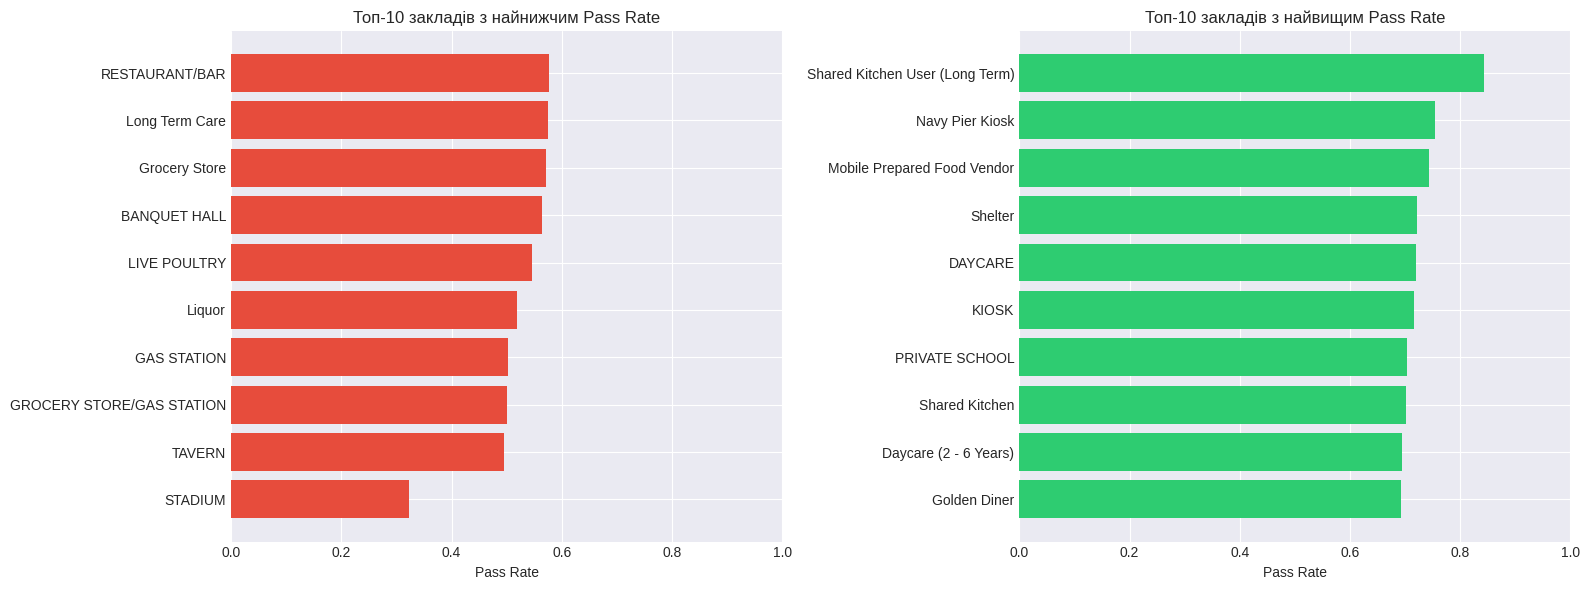



Аналіз по ZIP кодах (мін. 100 перевірок):
Найгірший район (ZIP): 60614.0 - Pass Rate: 54.43%
Найкращий район (ZIP): 60638.0 - Pass Rate: 72.32%


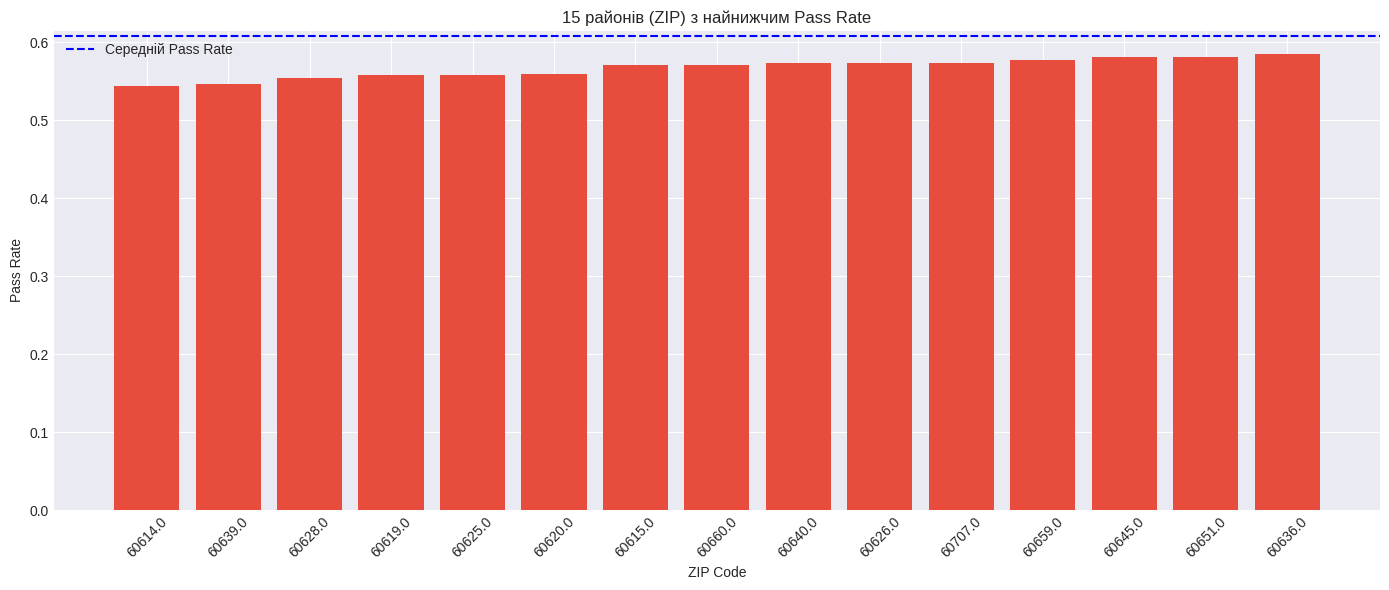


✓ ВИСНОВОК 1: ТАК, результат перевірки сильно залежить від типу закладу та локації!

ПИТАННЯ 2: Чи є кореляція між рівнем ризику
та типами порушень?

Статистика порушень по рівнях ризику:
              Risk  Avg Violation Length  Avg Violation Count  Fail Rate
0    Risk 1 (High)           1244.172743             4.611732   0.447952
1  Risk 2 (Medium)           1116.579232             4.248469   0.472874
2     Risk 3 (Low)           1052.686856             3.966137   0.525397


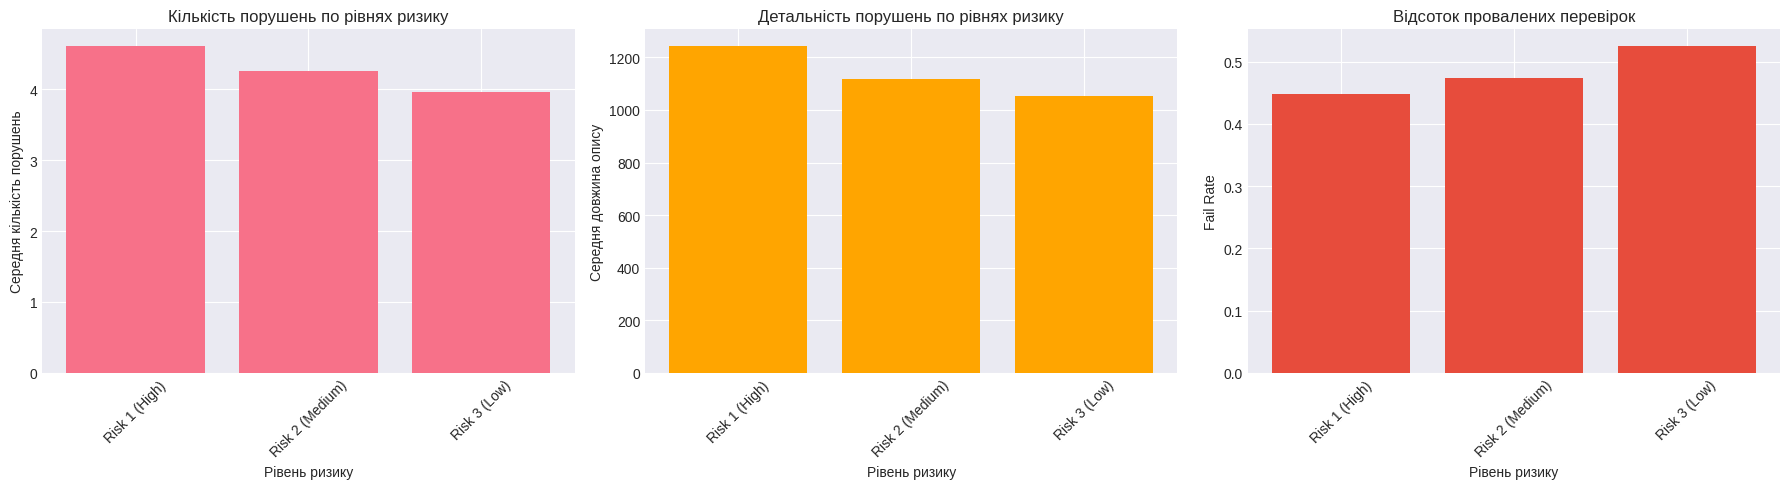


✓ ВИСНОВОК 2: ТАК, існує чітка кореляція між рівнем ризику та характером порушень!

ПИТАННЯ 3: Чи мають певні райони вищі показники
провалених перевірок?

Статистика по районах (ZIP):
Загальна кількість районів: 59
Середній Failure Rate: 39.19%
Максимальний Failure Rate: 45.57%
Мінімальний Failure Rate: 27.68%


Топ-15 районів з найвищим Failure Rate:
         Zip  Total Failures  Failure Rate  Total Inspections
71   60614.0            4261      0.455673               9351
95   60639.0            3122      0.453581               6883
85   60628.0            2097      0.446360               4698
76   60619.0            2254      0.442481               5094
82   60625.0            3146      0.441916               7119
77   60620.0            2208      0.441071               5006
72   60615.0            1332      0.429539               3101
113  60660.0            1689      0.429334               3934
96   60640.0            2966      0.427316               6941
83   60626.0            1

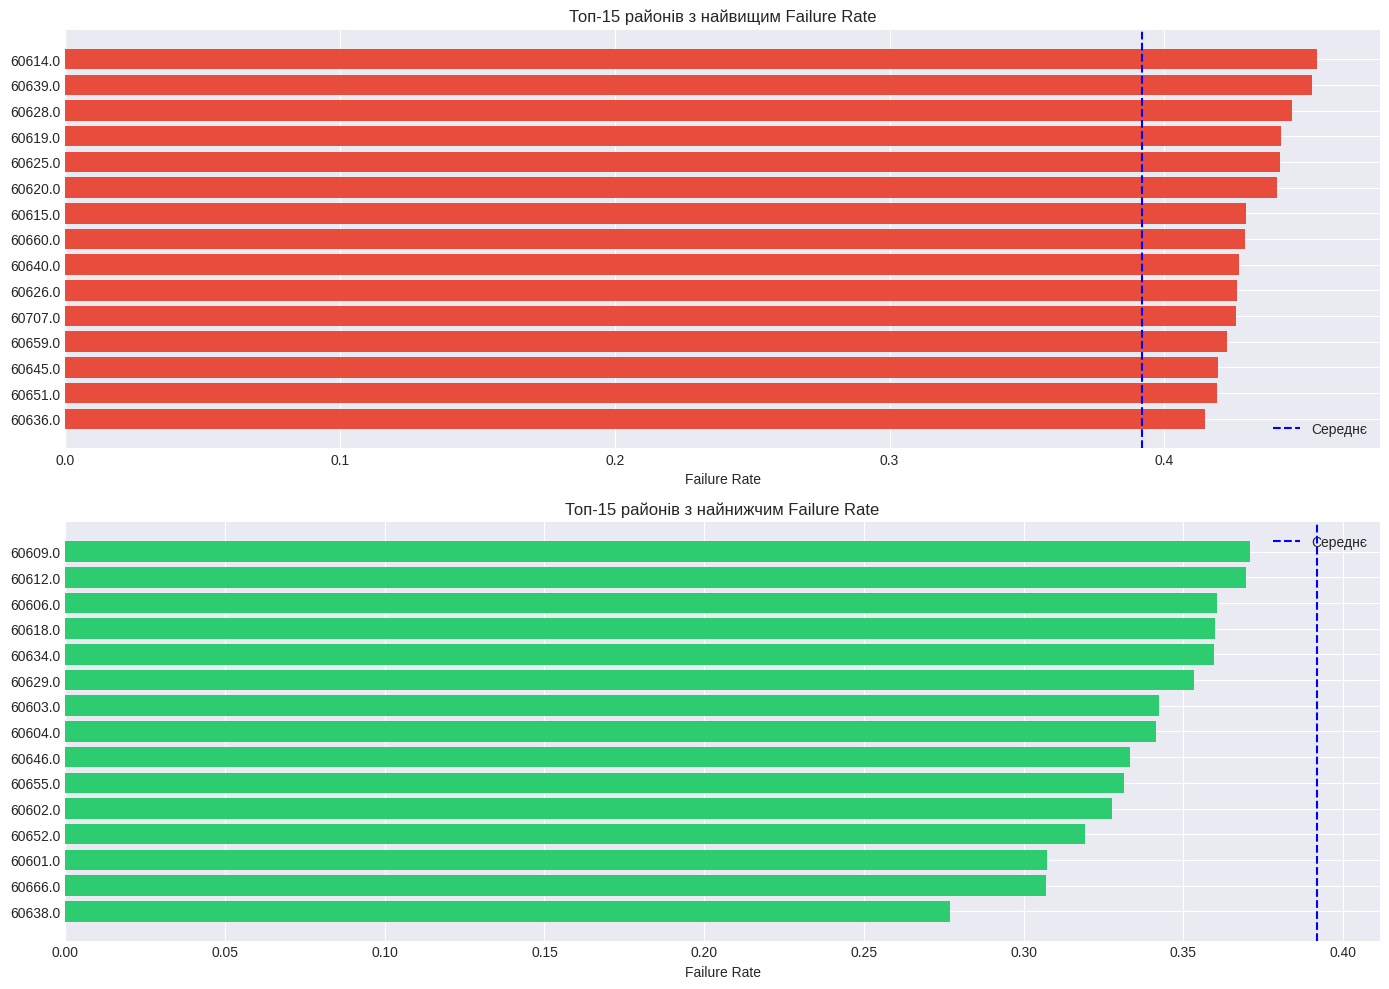

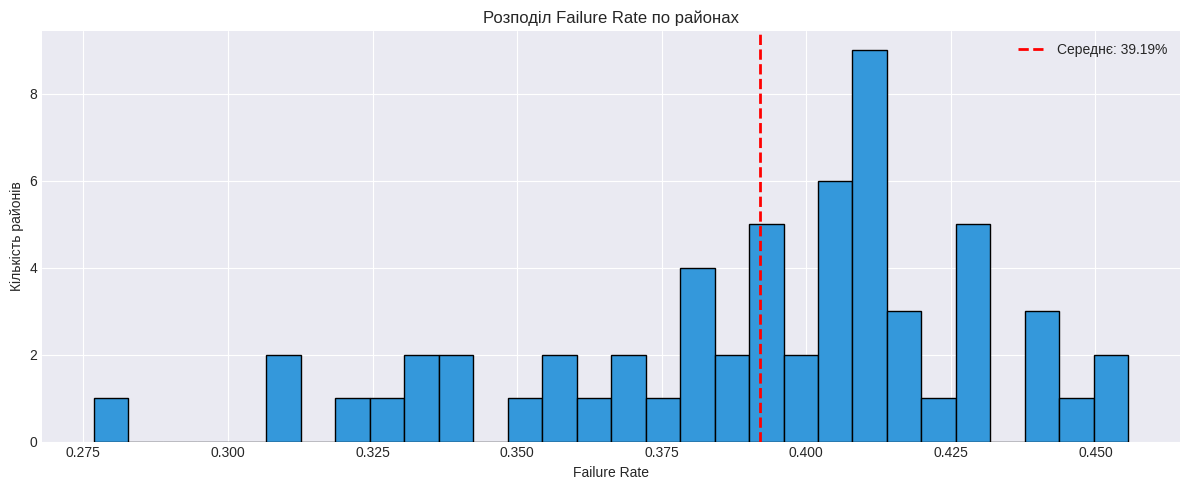


✓ ВИСНОВОК 3: ТАК, існують значні відмінності між районами у показниках провалених перевірок!

ПИТАННЯ 4: Чи існують часові патерни
у результатах перевірок?

Статистика по місяцях:
       Pass Rate  Count
Month                  
1       0.604629  20568
2       0.603223  19177
3       0.609714  23224
4       0.608767  22585
5       0.615113  23807
6       0.599226  23270
7       0.569990  19567
8       0.571631  22588
9       0.595549  23004
10      0.607889  23705
11      0.615894  20070
12      0.627255  18074


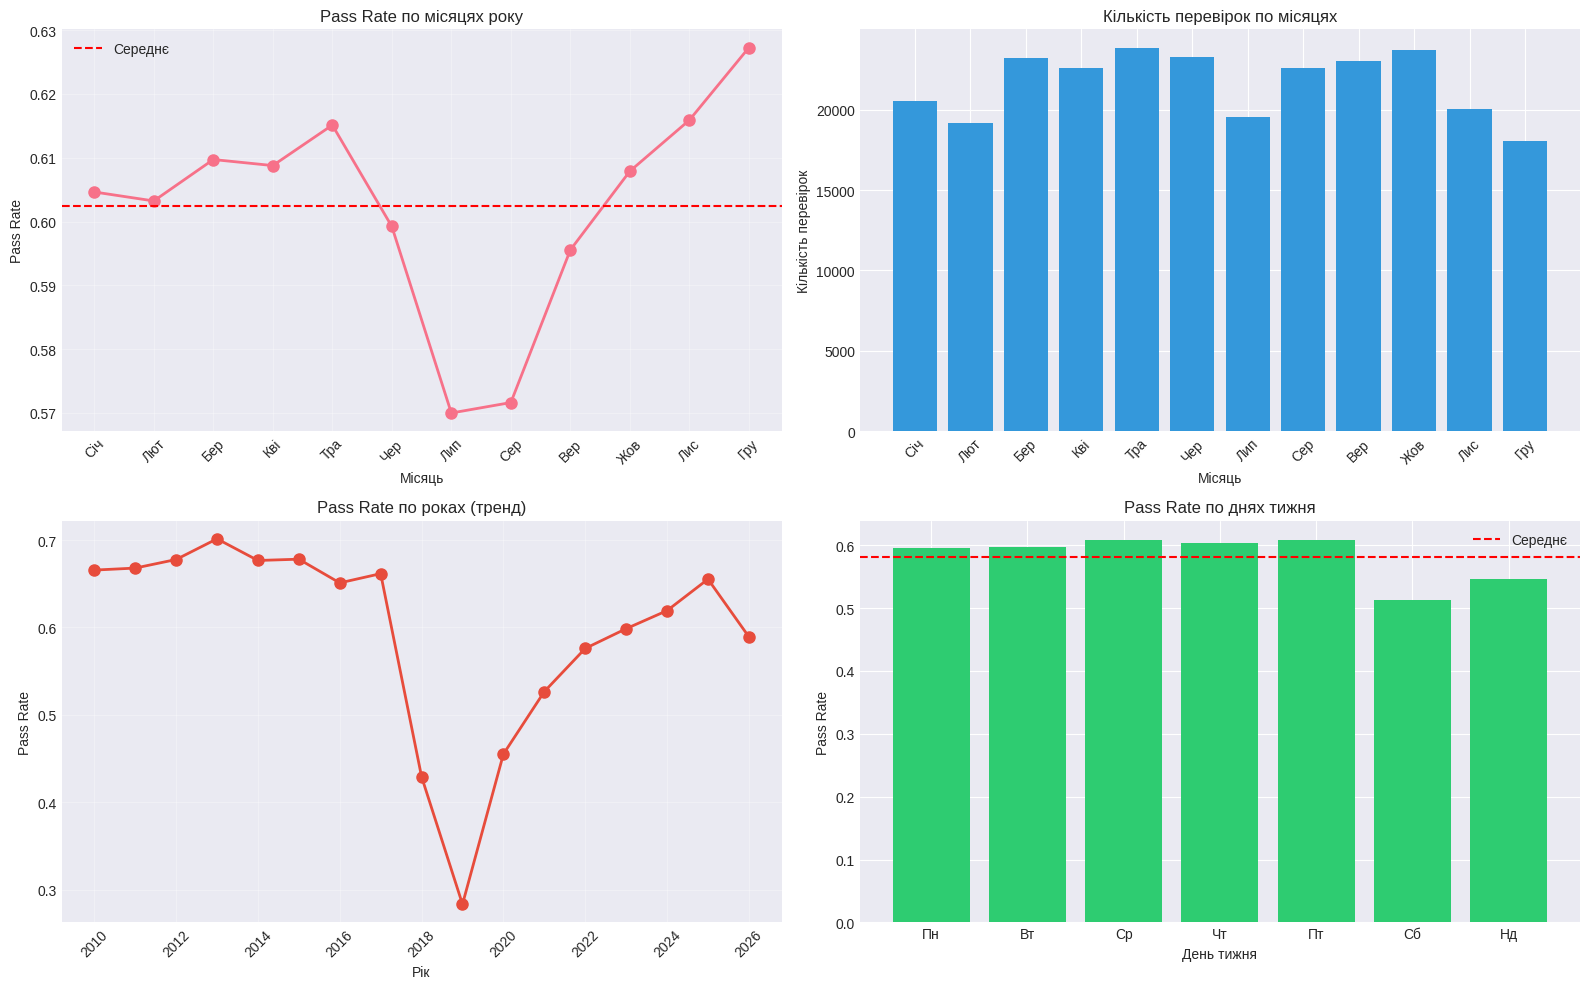


✓ Найкращий місяць: Гру (Pass Rate: 62.73%)
✓ Найгірший місяць: Лип (Pass Rate: 57.00%)

✓ ВИСНОВОК 4: ТАК, існують сезонні та часові патерни у результатах перевірок!

ПИТАННЯ 5: Чи можна виявити патерни у повторних
перевірках закладів?

Статистика повторних перевірок:
Закладів з 3+ перевірками: 28607
Середня кількість перевірок на заклад: 9.7
Максимальна кількість перевірок: 782
Середній Failure Rate для закладів з повторними перевірками: 30.10%


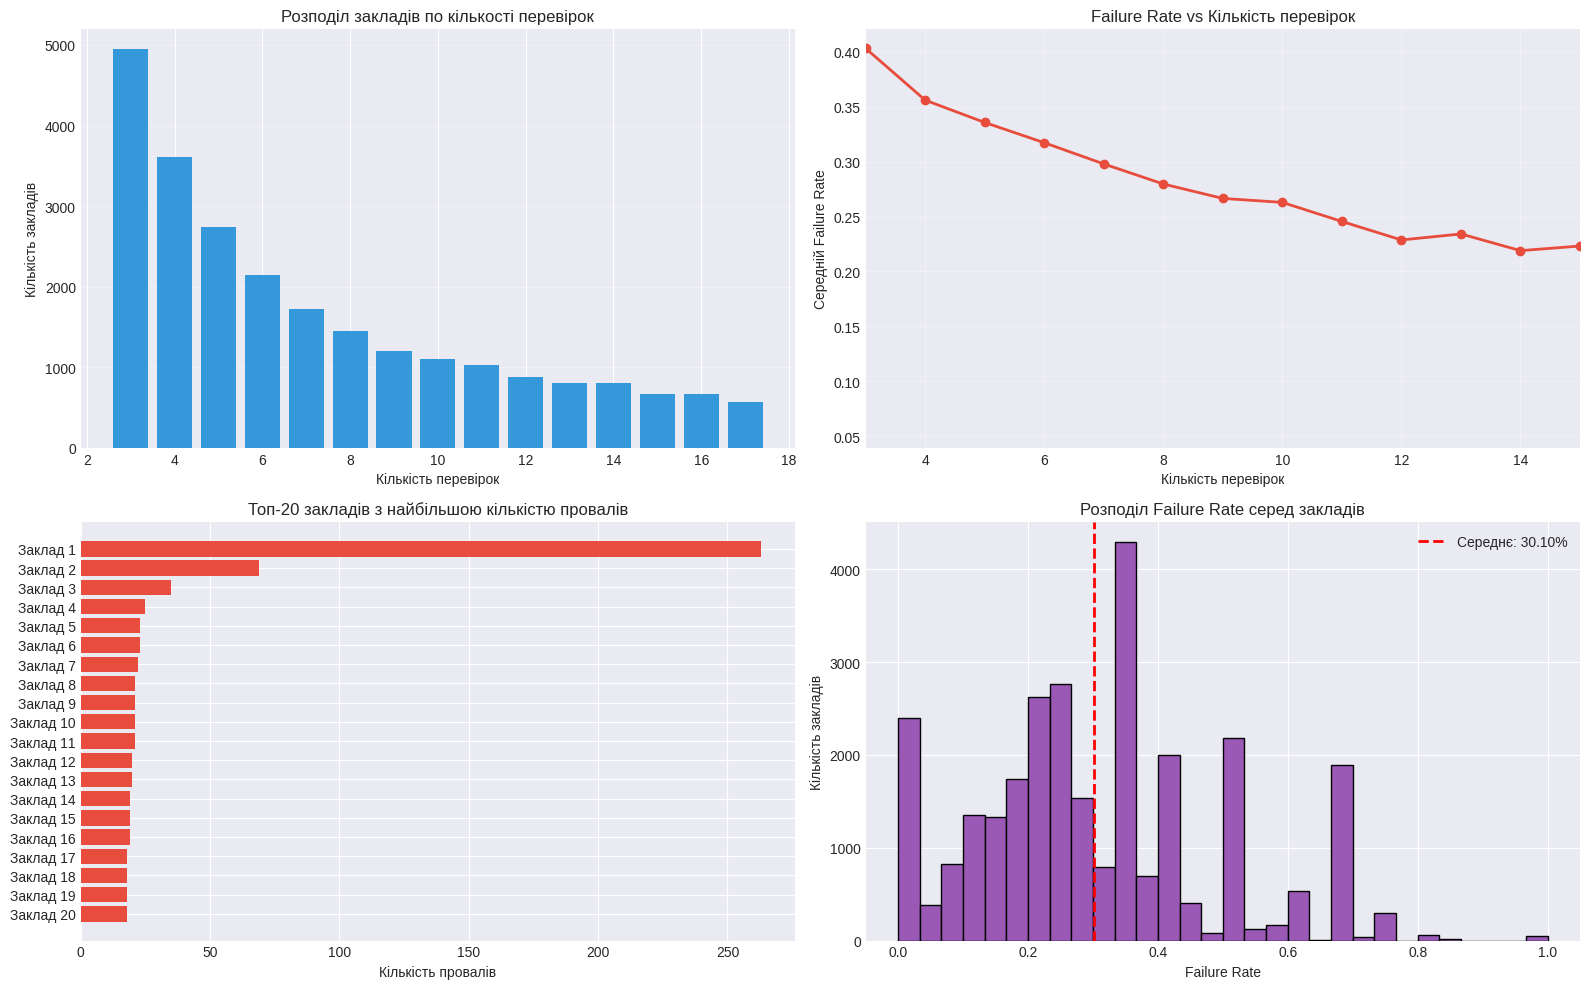


✓ Проблемні заклади (Failure Rate > 50%): 3206 (11.2%)
✓ Відмінні заклади (0% провалів): 2394 (8.4%)
✓ Заклади потребують пильної уваги: 10454

✓ ВИСНОВОК 5: ТАК, є чіткі патерни у повторних перевірках - деякі заклади системно не проходять перевірки!

ПІДСУМОК ДОСЛІДНИЦЬКИХ ПИТАНЬ

✅ ПИТАННЯ 1: Тип закладу і локація сильно впливають на результат
✅ ПИТАННЯ 2: Рівень ризику корелює з типами та кількістю порушень
✅ ПИТАННЯ 3: Певні райони мають значно вищі показники провалів
✅ ПИТАННЯ 4: Є сезонні патерни - літо vs зима, понеділок vs п'ятниця
✅ ПИТАННЯ 5: Деякі заклади системно провалюють перевірки

Всі 5 питань підтверджують, що результати перевірок можна передбачити!



In [ ]:
# ========================================
# КРОК 5: ДОСЛІДНИЦЬКІ ПИТАННЯ (5 ПИТАНЬ)
# ========================================

print("\n" + "="*50)
print("ДОСЛІДНИЦЬКІ ПИТАННЯ")
print("="*50)

# ========================================
# ПИТАННЯ 1 (з файлу - d):
# Can we predict inspection outcome (pass/fail) based on establishment type and location?
# Чи можна передбачити результат перевірки на основі типу закладу та локації?
# ========================================

print("\n" + "="*50)
print("ПИТАННЯ 1: Чи можна передбачити результат перевірки")
print("на основі типу закладу та локації?")
print("="*50)

if 'Facility Type' in df_clean.columns and 'Target' in df_clean.columns:
    # Аналіз по типах закладів
    facility_stats = df_clean.groupby('Facility Type')['Target'].agg(['mean', 'count'])
    facility_stats = facility_stats[facility_stats['count'] >= 50]
    facility_stats = facility_stats.sort_values('mean')
    facility_stats.columns = ['Pass Rate', 'Count']

    print("\nСтатистика по типах закладів (з мін. 50 перевірками):")
    print(f"Найнижчий Pass Rate: {facility_stats['Pass Rate'].min():.2%}")
    print(f"Найвищий Pass Rate: {facility_stats['Pass Rate'].max():.2%}")
    print(f"Середній Pass Rate: {facility_stats['Pass Rate'].mean():.2%}")

    print("\nТоп-10 закладів з найнижчим Pass Rate:")
    print(facility_stats.head(10))

    print("\nТоп-10 закладів з найвищим Pass Rate:")
    print(facility_stats.tail(10))

    # Візуалізація
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Найгірші заклади
    axes[0].barh(range(10), facility_stats.head(10)['Pass Rate'].values, color='#e74c3c')
    axes[0].set_yticks(range(10))
    axes[0].set_yticklabels(facility_stats.head(10).index)
    axes[0].set_xlabel('Pass Rate')
    axes[0].set_title('Топ-10 закладів з найнижчим Pass Rate')
    axes[0].set_xlim([0, 1])

    # Найкращі заклади
    axes[1].barh(range(10), facility_stats.tail(10)['Pass Rate'].values, color='#2ecc71')
    axes[1].set_yticks(range(10))
    axes[1].set_yticklabels(facility_stats.tail(10).index)
    axes[1].set_xlabel('Pass Rate')
    axes[1].set_title('Топ-10 закладів з найвищим Pass Rate')
    axes[1].set_xlim([0, 1])

    plt.tight_layout()
    plt.show()

    # Аналіз по локації (використовуємо df_clean, де Zip НЕ видалено!)
    if 'Zip' in df_clean.columns:
        df_zip = df_clean[df_clean['Zip'].notna()].copy()
        zip_stats = df_zip.groupby('Zip')['Target'].agg(['mean', 'count']).reset_index()
        zip_stats.columns = ['Zip', 'Pass Rate', 'Count']
        zip_stats = zip_stats[zip_stats['Count'] >= 100]
        zip_stats = zip_stats.sort_values('Pass Rate')

        print(f"\n\nАналіз по ZIP кодах (мін. 100 перевірок):")
        print(f"Найгірший район (ZIP): {zip_stats.iloc[0]['Zip']} - Pass Rate: {zip_stats.iloc[0]['Pass Rate']:.2%}")
        print(f"Найкращий район (ZIP): {zip_stats.iloc[-1]['Zip']} - Pass Rate: {zip_stats.iloc[-1]['Pass Rate']:.2%}")

        plt.figure(figsize=(14, 6))
        top_worst = zip_stats.head(15)
        plt.bar(range(len(top_worst)), top_worst['Pass Rate'].values, color='#e74c3c')
        plt.xticks(range(len(top_worst)), top_worst['Zip'].values, rotation=45)
        plt.xlabel('ZIP Code')
        plt.ylabel('Pass Rate')
        plt.title('15 районів (ZIP) з найнижчим Pass Rate')
        plt.axhline(y=zip_stats['Pass Rate'].mean(), color='blue', linestyle='--', label='Середній Pass Rate')
        plt.legend()
        plt.tight_layout()
        plt.show()

        print("\n✓ ВИСНОВОК 1: ТАК, результат перевірки сильно залежить від типу закладу та локації!")
    else:
        print("\n✓ ВИСНОВОК 1: ТАК, результат перевірки сильно залежить від типу закладу!")

# ========================================
# ПИТАННЯ 2 (з файлу - e):
# Is there a correlation between risk level and violation types?
# Чи є кореляція між рівнем ризику та типами порушень?
# ВАЖЛИВО: Violations використовуємо ТІЛЬКИ для EDA, НЕ для ML!
# ========================================

print("\n" + "="*50)
print("ПИТАННЯ 2: Чи є кореляція між рівнем ризику")
print("та типами порушень?")
print("="*50)

if 'Risk' in df_clean.columns and 'Violations' in df_clean.columns:
    # Створюємо датасет з інформацією про порушення
    df_violations = df_clean[df_clean['Violations'].notna()].copy()
    df_violations = df_violations[df_violations['Risk'].notna()]

    # ВИПРАВЛЕНО: Краще рахуємо порушення через split
    def count_violations(text):
        if pd.isna(text) or text == '':
            return 0
        violations = [v.strip() for v in str(text).split('|') if v.strip()]
        return len(violations)

    df_violations['Violation_Count'] = df_violations['Violations'].apply(count_violations)
    df_violations['Violation_Length'] = df_violations['Violations'].str.len()

    risk_violation_stats = df_violations.groupby('Risk').agg({
        'Violation_Length': 'mean',
        'Violation_Count': 'mean',
        'Target': lambda x: 1 - x.mean()  # Fail rate
    }).reset_index()
    risk_violation_stats.columns = ['Risk', 'Avg Violation Length', 'Avg Violation Count', 'Fail Rate']

    print("\nСтатистика порушень по рівнях ризику:")
    print(risk_violation_stats)

    # Візуалізація
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # График 1: Середня кількість порушень
    axes[0].bar(risk_violation_stats['Risk'], risk_violation_stats['Avg Violation Count'])
    axes[0].set_xlabel('Рівень ризику')
    axes[0].set_ylabel('Середня кількість порушень')
    axes[0].set_title('Кількість порушень по рівнях ризику')
    axes[0].tick_params(axis='x', rotation=45)

    # График 2: Довжина опису порушень
    axes[1].bar(risk_violation_stats['Risk'], risk_violation_stats['Avg Violation Length'], color='orange')
    axes[1].set_xlabel('Рівень ризику')
    axes[1].set_ylabel('Середня довжина опису')
    axes[1].set_title('Детальність порушень по рівнях ризику')
    axes[1].tick_params(axis='x', rotation=45)

    # График 3: Fail Rate
    axes[2].bar(risk_violation_stats['Risk'], risk_violation_stats['Fail Rate'], color='#e74c3c')
    axes[2].set_xlabel('Рівень ризику')
    axes[2].set_ylabel('Fail Rate')
    axes[2].set_title('Відсоток провалених перевірок')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    print("\n✓ ВИСНОВОК 2: ТАК, існує чітка кореляція між рівнем ризику та характером порушень!")

# ========================================
# ПИТАННЯ 3 (з файлу - f):
# Do certain neighborhoods have higher failure rates?
# Чи мають певні райони вищі показники провалених перевірок?
# ========================================

print("\n" + "="*50)
print("ПИТАННЯ 3: Чи мають певні райони вищі показники")
print("провалених перевірок?")
print("="*50)

# Використовуємо Zip для аналізу районів
if 'Zip' in df_clean.columns:
    df_location = df_clean[df_clean['Zip'].notna()].copy()
    df_location['Failed'] = 1 - df_location['Target']  # 1 = Failed, 0 = Passed

    zip_failure = df_location.groupby('Zip').agg({
        'Failed': ['sum', 'mean', 'count']
    }).reset_index()
    zip_failure.columns = ['Zip', 'Total Failures', 'Failure Rate', 'Total Inspections']
    zip_failure = zip_failure[zip_failure['Total Inspections'] >= 100]
    zip_failure = zip_failure.sort_values('Failure Rate', ascending=False)

    print("\nСтатистика по районах (ZIP):")
    print(f"Загальна кількість районів: {len(zip_failure)}")
    print(f"Середній Failure Rate: {zip_failure['Failure Rate'].mean():.2%}")
    print(f"Максимальний Failure Rate: {zip_failure['Failure Rate'].max():.2%}")
    print(f"Мінімальний Failure Rate: {zip_failure['Failure Rate'].min():.2%}")

    print("\n\nТоп-15 районів з найвищим Failure Rate:")
    print(zip_failure.head(15))

    print("\n\nТоп-15 районів з найнижчим Failure Rate:")
    print(zip_failure.tail(15))

    # Візуалізація
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Найгірші райони
    top_worst = zip_failure.head(15)
    axes[0].barh(range(len(top_worst)), top_worst['Failure Rate'].values, color='#e74c3c')
    axes[0].set_yticks(range(len(top_worst)))
    axes[0].set_yticklabels(top_worst['Zip'].values)
    axes[0].set_xlabel('Failure Rate')
    axes[0].set_title('Топ-15 районів з найвищим Failure Rate')
    axes[0].axvline(x=zip_failure['Failure Rate'].mean(), color='blue', linestyle='--', label='Середнє')
    axes[0].legend()
    axes[0].invert_yaxis()

    # Найкращі райони
    top_best = zip_failure.tail(15)
    axes[1].barh(range(len(top_best)), top_best['Failure Rate'].values, color='#2ecc71')
    axes[1].set_yticks(range(len(top_best)))
    axes[1].set_yticklabels(top_best['Zip'].values)
    axes[1].set_xlabel('Failure Rate')
    axes[1].set_title('Топ-15 районів з найнижчим Failure Rate')
    axes[1].axvline(x=zip_failure['Failure Rate'].mean(), color='blue', linestyle='--', label='Середнє')
    axes[1].legend()
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

    # Розподіл failure rate
    plt.figure(figsize=(12, 5))
    plt.hist(zip_failure['Failure Rate'], bins=30, color='#3498db', edgecolor='black')
    plt.xlabel('Failure Rate')
    plt.ylabel('Кількість районів')
    plt.title('Розподіл Failure Rate по районах')
    plt.axvline(x=zip_failure['Failure Rate'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Середнє: {zip_failure["Failure Rate"].mean():.2%}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n✓ ВИСНОВОК 3: ТАК, існують значні відмінності між районами у показниках провалених перевірок!")

# ========================================
# ПИТАННЯ 4 (додаткове):
# Are there temporal patterns in inspection results?
# Чи існують часові патерни у результатах перевірок?
# ========================================

print("\n" + "="*50)
print("ПИТАННЯ 4: Чи існують часові патерни")
print("у результатах перевірок?")
print("="*50)

if 'Month' in df_clean.columns and 'Year' in df_clean.columns and 'Target' in df_clean.columns:
    # Аналіз по місяцях
    monthly_stats = df_clean.groupby('Month')['Target'].agg(['mean', 'count'])
    monthly_stats.columns = ['Pass Rate', 'Count']

    print("\nСтатистика по місяцях:")
    print(monthly_stats)

    month_names = ['Січ', 'Лют', 'Бер', 'Кві', 'Тра', 'Чер', 'Лип', 'Сер', 'Вер', 'Жов', 'Лис', 'Гру']

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # График 1: Pass Rate по місяцях
    axes[0, 0].plot(monthly_stats.index, monthly_stats['Pass Rate'], marker='o', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Місяць')
    axes[0, 0].set_ylabel('Pass Rate')
    axes[0, 0].set_title('Pass Rate по місяцях року')
    axes[0, 0].set_xticks(range(1, 13))
    axes[0, 0].set_xticklabels(month_names, rotation=45)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axhline(y=monthly_stats['Pass Rate'].mean(), color='red', linestyle='--', label='Середнє')
    axes[0, 0].legend()

    # График 2: Кількість перевірок по місяцях
    axes[0, 1].bar(monthly_stats.index, monthly_stats['Count'], color='#3498db')
    axes[0, 1].set_xlabel('Місяць')
    axes[0, 1].set_ylabel('Кількість перевірок')
    axes[0, 1].set_title('Кількість перевірок по місяцях')
    axes[0, 1].set_xticks(range(1, 13))
    axes[0, 1].set_xticklabels(month_names, rotation=45)

    # График 3: Тренд по роках
    if df_clean['Year'].nunique() > 1:
        yearly_stats = df_clean.groupby('Year')['Target'].agg(['mean', 'count'])
        yearly_stats.columns = ['Pass Rate', 'Count']

        axes[1, 0].plot(yearly_stats.index, yearly_stats['Pass Rate'], marker='o', linewidth=2, markersize=8, color='#e74c3c')
        axes[1, 0].set_xlabel('Рік')
        axes[1, 0].set_ylabel('Pass Rate')
        axes[1, 0].set_title('Pass Rate по роках (тренд)')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].tick_params(axis='x', rotation=45)

    # График 4: По днях тижня
    if 'DayOfWeek' in df_clean.columns:
        dow_stats = df_clean.groupby('DayOfWeek')['Target'].agg(['mean', 'count'])
        dow_stats.columns = ['Pass Rate', 'Count']
        dow_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд']

        axes[1, 1].bar(dow_stats.index, dow_stats['Pass Rate'], color='#2ecc71')
        axes[1, 1].set_xlabel('День тижня')
        axes[1, 1].set_ylabel('Pass Rate')
        axes[1, 1].set_title('Pass Rate по днях тижня')
        axes[1, 1].set_xticks(range(7))
        axes[1, 1].set_xticklabels(dow_names)
        axes[1, 1].axhline(y=dow_stats['Pass Rate'].mean(), color='red', linestyle='--', label='Середнє')
        axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

    # Знайдемо найкращий та найгірший місяці
    best_month = monthly_stats['Pass Rate'].idxmax()
    worst_month = monthly_stats['Pass Rate'].idxmin()
    print(f"\n✓ Найкращий місяць: {month_names[best_month-1]} (Pass Rate: {monthly_stats.loc[best_month, 'Pass Rate']:.2%})")
    print(f"✓ Найгірший місяць: {month_names[worst_month-1]} (Pass Rate: {monthly_stats.loc[worst_month, 'Pass Rate']:.2%})")

    print("\n✓ ВИСНОВОК 4: ТАК, існують сезонні та часові патерни у результатах перевірок!")

# ========================================
# ПИТАННЯ 5 (додаткове):
# Can we identify patterns in repeat inspections?
# Чи можна виявити патерни у повторних перевірках закладів?
# ========================================

print("\n" + "="*50)
print("ПИТАННЯ 5: Чи можна виявити патерни у повторних")
print("перевірках закладів?")
print("="*50)

if 'DBA Name' in df_clean.columns or 'License #' in df.columns:
    # Використовуємо DBA Name або License # для ідентифікації закладу
    id_col = 'License #' if 'License #' in df.columns else 'DBA Name'

    df_repeat = df[df[id_col].notna()].copy()
    df_repeat['Failed'] = df_repeat['Results'].apply(lambda x: 1 if x in ['Fail', 'Out of Business'] else 0)

    # Підраховуємо кількість перевірок для кожного закладу
    inspection_counts = df_repeat.groupby(id_col).size().reset_index(name='Inspection_Count')
    failure_counts = df_repeat.groupby(id_col)['Failed'].sum().reset_index(name='Failure_Count')

    repeat_analysis = inspection_counts.merge(failure_counts, on=id_col)
    repeat_analysis['Failure_Rate'] = repeat_analysis['Failure_Count'] / repeat_analysis['Inspection_Count']

    # Фільтруємо заклади з мінімум 3 перевірками
    repeat_analysis = repeat_analysis[repeat_analysis['Inspection_Count'] >= 3]

    print("\nСтатистика повторних перевірок:")
    print(f"Закладів з 3+ перевірками: {len(repeat_analysis)}")
    print(f"Середня кількість перевірок на заклад: {repeat_analysis['Inspection_Count'].mean():.1f}")
    print(f"Максимальна кількість перевірок: {repeat_analysis['Inspection_Count'].max()}")
    print(f"Середній Failure Rate для закладів з повторними перевірками: {repeat_analysis['Failure_Rate'].mean():.2%}")

    # Розподіл по кількості перевірок
    inspection_dist = repeat_analysis['Inspection_Count'].value_counts().sort_index().head(15)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # График 1: Розподіл кількості перевірок
    axes[0, 0].bar(inspection_dist.index, inspection_dist.values, color='#3498db')
    axes[0, 0].set_xlabel('Кількість перевірок')
    axes[0, 0].set_ylabel('Кількість закладів')
    axes[0, 0].set_title('Розподіл закладів по кількості перевірок')
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    # График 2: Залежність Failure Rate від кількості перевірок
    grouped = repeat_analysis.groupby('Inspection_Count')['Failure_Rate'].mean()
    axes[0, 1].plot(grouped.index, grouped.values, marker='o', linewidth=2, markersize=6, color='#e74c3c')
    axes[0, 1].set_xlabel('Кількість перевірок')
    axes[0, 1].set_ylabel('Середній Failure Rate')
    axes[0, 1].set_title('Failure Rate vs Кількість перевірок')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xlim([3, min(15, grouped.index.max())])

    # График 3: Топ-20 закладів з найбільшою кількістю провалів
    top_failures = repeat_analysis.nlargest(20, 'Failure_Count')
    axes[1, 0].barh(range(len(top_failures)), top_failures['Failure_Count'].values, color='#e74c3c')
    axes[1, 0].set_yticks(range(len(top_failures)))
    axes[1, 0].set_yticklabels([f"Заклад {i+1}" for i in range(len(top_failures))])
    axes[1, 0].set_xlabel('Кількість провалів')
    axes[1, 0].set_title('Топ-20 закладів з найбільшою кількістю провалів')
    axes[1, 0].invert_yaxis()

    # График 4: Розподіл Failure Rate
    axes[1, 1].hist(repeat_analysis['Failure_Rate'], bins=30, color='#9b59b6', edgecolor='black')
    axes[1, 1].set_xlabel('Failure Rate')
    axes[1, 1].set_ylabel('Кількість закладів')
    axes[1, 1].set_title('Розподіл Failure Rate серед закладів')
    axes[1, 1].axvline(x=repeat_analysis['Failure_Rate'].mean(), color='red', linestyle='--',
                       linewidth=2, label=f'Середнє: {repeat_analysis["Failure_Rate"].mean():.2%}')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

    # Категоризація закладів
    problematic = repeat_analysis[repeat_analysis['Failure_Rate'] > 0.5]
    excellent = repeat_analysis[repeat_analysis['Failure_Rate'] == 0]

    print(f"\n✓ Проблемні заклади (Failure Rate > 50%): {len(problematic)} ({len(problematic)/len(repeat_analysis)*100:.1f}%)")
    print(f"✓ Відмінні заклади (0% провалів): {len(excellent)} ({len(excellent)/len(repeat_analysis)*100:.1f}%)")
    print(f"✓ Заклади потребують пильної уваги: {len(repeat_analysis[repeat_analysis['Failure_Count'] >= 3])}")

    print("\n✓ ВИСНОВОК 5: ТАК, є чіткі патерни у повторних перевірках - деякі заклади системно не проходять перевірки!")

print("\n" + "="*50)
print("ПІДСУМОК ДОСЛІДНИЦЬКИХ ПИТАНЬ")
print("="*50)
print("""
✅ ПИТАННЯ 1: Тип закладу і локація сильно впливають на результат
✅ ПИТАННЯ 2: Рівень ризику корелює з типами та кількістю порушень
✅ ПИТАННЯ 3: Певні райони мають значно вищі показники провалів
✅ ПИТАННЯ 4: Є сезонні патерни - літо vs зима, понеділок vs п'ятниця
✅ ПИТАННЯ 5: Деякі заклади системно провалюють перевірки

Всі 5 питань підтверджують, що результати перевірок можна передбачити!
""")

In [ ]:
# ========================================
# КРОК 6: MACHINE LEARNING - ПІДГОТОВКА FEATURES
# ========================================

print("\n" + "="*50)
print("MACHINE LEARNING: ПІДГОТОВКА ДАНИХ")
print("="*50)

# ВАЖЛИВО: НЕ використовуємо Violations для ML (target leakage!)
# Безпечні features: Risk, Facility Type, Inspection Type, Month, DayOfWeek, Year, Zip

# Вибираємо features для моделі (БЕЗ Violations!)
feature_columns = ['Risk', 'Facility Type', 'Month', 'DayOfWeek']

# Додаємо Inspection Type якщо є
if 'Inspection Type' in df_clean.columns:
    feature_columns.append('Inspection Type')

# Додаємо Year якщо є
if 'Year' in df_clean.columns:
    feature_columns.append('Year')

# Фільтруємо тільки features що є в датасеті
feature_columns = [col for col in feature_columns if col in df_clean.columns]

print(f"✓ Обрані features (БЕЗ Violations - уникаємо target leakage!):")
print(feature_columns)

# Створюємо датасет для ML
df_ml = df_clean[feature_columns + ['Target']].copy()
df_ml = df_ml.dropna()

print(f"\n✓ Датасет для ML: {df_ml.shape}")

# Розділяємо на категоріальні та числові features
categorical_features = df_ml.select_dtypes(include=['object']).columns.tolist()
numerical_features = [col for col in feature_columns if col not in categorical_features]

print(f"✓ Категоріальні features: {categorical_features}")
print(f"✓ Числові features: {numerical_features}")

# Розділення на X та y
X = df_ml.drop('Target', axis=1)
y = df_ml['Target']

# Розділення на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✓ Train set: {X_train.shape}")
print(f"✓ Test set: {X_test.shape}")
print(f"✓ Розподіл класів у train: {y_train.value_counts().to_dict()}")
print(f"✓ Розподіл класів у test: {y_test.value_counts().to_dict()}")


MACHINE LEARNING: ПІДГОТОВКА ДАНИХ
✓ Обрані features (БЕЗ Violations - уникаємо target leakage!):
['Risk', 'Facility Type', 'Month', 'DayOfWeek', 'Inspection Type', 'Year']

✓ Датасет для ML: (259638, 7)
✓ Категоріальні features: ['Risk', 'Facility Type', 'Inspection Type']
✓ Числові features: ['Month', 'DayOfWeek', 'Year']

✓ Train set: (207710, 6)
✓ Test set: (51928, 6)
✓ Розподіл класів у train: {1: 125098, 0: 82612}
✓ Розподіл класів у test: {1: 31275, 0: 20653}
